<a href="https://colab.research.google.com/github/nuoxi3007/data-analysis-projects/blob/main/%2001-pc-market-analysis/DATA-Analyze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ онлайн-магазина персональных компьютеров
## Проект по стажировке Цифровой кафедры "Аналитика данных" (Уровень ADVANCED)

### Введение

К нам обратился клиент, занимающийся сборкой и продажей персональных компьютеров (за исключением мини-ПК и моноблоков). В связи с ростом популярности интернет-магазинов (Wildberries, Ozon, OnlineTrade и т.п.) и с целью привлечения большего числа клиентов при одновременном снижении затрат на содержание собственного магазина, доставку и рекламу товаров на 10%, клиент планирует выйти на онлайн-рынок в ближайшие 3 месяца.

В связи с этим Заказчик хотел бы узнать, от чего зависит цена, а также популярность персональных компьютеров, выкладываемых на онлайн-площадках. Это позволит ему в дальнейшем планировать к сборке востребованные по техническим характеристикам компьютеры и продавать их по конкурентной цене.

Специалистом по сбору данных были выгружены датасеты с одного из популярных онлайн-магазинов, содержащие информацию о товарах категории «Компьютеры и моноблоки». Цель данного анализа — проанализировать полученные данные и представить аналитический отчет, содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения его бизнес-задач.

## 1. Business Understanding / Бизнес-анализ

На этом этапе было проведено углубленное понимание бизнес-модели Заказчика, его ключевых показателей эффективности и стратегических целей. Основные аспекты:
* **Бизнес Заказчика:** Сборка и продажа персональных компьютеров (кроме мини-ПК и моноблоков).
* **Цель:** Выход на онлайн-рынок в ближайшие 3 месяца.
* **Задачи:** Привлечение большего числа клиентов, снижение затрат на содержание магазина, доставку и рекламу товаров на 10%.
* **Ключевой вопрос:** От чего зависит цена и популярность персональных компьютеров на онлайн-площадках?
* **Предмет анализа:** Цена и популярность (количество продаж) персональных компьютеров, а также их зависимость от комплектующих (на основе датасета `wb_pc_hard.csv`).
* **Результат:** Формирование рекомендаций по планированию сборки востребованных ПК и установлению конкурентных цен.

## 2. Data Understanding / Изучение данных

На этом этапе осуществляется первичное изучение предоставленных Заказчиком исходных данных, определение проблем в этих данных, выделение значимой для анализа информации.

### Описание исходных данных
Специалистом по сбору данных был выгружен датасет `wb_pc_hard.csv` с одного из популярных онлайн-магазинов, содержащий информацию о товарах категории «Компьютеры и моноблоки».

**Структура датасета `wb_pc_hard.csv` включает следующие признаки:**
* `product_id`: идентификатор товара
* `title`: наименование товара
* `price`: цена товара в руб.
* `sales`: количество продаж
* `feedbacks`: количество отзывов
* `seller`: наименование продавца
* `seller_rating`: рейтинг продавца
* `Процессор`: данные о процессоре
    * `Процессор_тип`: тип процессора
    * `Количество ядер процессора`: количество ядер процессора
* `Оперативная память`: данные об оперативной памяти
    * `Тип оперативной памяти`: тип оперативной памяти
    * `Объем оперативной памяти (Гб)`: объем оперативной памяти в Гб
* `Жесткий диск`: данные об жестком диске
    * `Объем накопителя HDD`: объем накопителя HDD
    * `Объем накопителя SSD`: объем накопителя SSD
* `Видеопроцессор`: данные о видеопроцессоре
* `Операционная система`: данные об операционной системе
* `Гарантийный срок`: данные о гарантийном сроке
* `Страна производства`: страна производства
* `Габариты товара`: данные о габарите товара
    * `Ширина предмета`: ширина предмета
    * `Глубина предмета`: глубина предмета
    * `Высота предмета`: высота предмета
    * `Вес без упаковки (кг)`: вес без упаковки в кг
* `Габариты товара (с упаковкой)`: данные о габарите товара с упаковкой
    * `Длина упаковки`: длина упаковки
    * `Ширина упаковки`: ширина упаковки
    * `Высота упаковки`: высота упаковки
    * `Вес с упаковкой (кг)`: вес с упаковкой в кг

## 3. Подготовка данных (Data Preparation)

На этом этапе проводится очистка, преобразование данных, создание новых признаков и их нормализация для подготовки к дальнейшему анализу и моделированию.

### Загрузка и первичный обзор данных

### Этап: Предобработка данных

### Импорт необходимых библиотек и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import re
import ast  # Для распаковки словарей из строк
import warnings

warnings.filterwarnings('ignore')

# Загрузка данных
df_raw = pd.read_csv('wb_pc_hard.csv')
df_raw.sample(5)


,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
3664,150691616,Игровой компьютер Fighter M2 White,77264₽,NaN,0 отзывов,M-Bit,0.0,"{'Процессор_тип': 'Intel Core i7', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce RTX 2060,Windows 11 Pro,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
3704,150935977,Игровой компьютер Strateg M2,79200₽,NaN,0 отзывов,M-Bit,0.0,"{'Процессор_тип': 'Intel Core i7', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce RTX 3050,Windows 11 Pro,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
91,38114033,Компьютер,892₽,NaN,0 отзывов,САТЕЛЛИТ,4.7,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '15 см', 'Ширина упаковки':..."
944,99021851,Игровой компьютер BK 9951 White,74872₽,Купили менее 5 раз,0 отзывов,Buchok,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",NVIDIA GeForce RTX 3050,Windows 10 Pro,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '25 см', 'Ширина упаковки':..."
4491,152959200,Игровой компьютер,77250₽,NaN,0 отзывов,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",NVIDIA,Windows 10,1 год,NaN,"{'Ширина предмета': '30 см', 'Глубина предмета...","{'Длина упаковки': '40 см', 'Ширина упаковки':..."


#### Общая информация о данных

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4500 non-null   int64  
 1   title                          4500 non-null   object 
 2   price                          4499 non-null   object 
 3   sales                          1164 non-null   object 
 4   feedbacks                      4500 non-null   object 
 5   seller                         4391 non-null   object 
 6   seller_rating                  4389 non-null   float64
 7   Процессор                      4500 non-null   object 
 8   Оперативная память             4500 non-null   object 
 9   Жесткий диск                   4500 non-null   object 
 10  Видеопроцессор                 4500 non-null   object 
 11  Операционная система           4500 non-null   object 
 12  Гарантийный срок               2648 non-null   o

#### Пример случайных строк из датасета

In [ ]:
df_raw.sample(5)

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
294,56377305,Игровой компьютер Roo24 Gaming S4 Plus,47167₽,Купили менее 5 раз,0 отзывов,Roo24.ru,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GT 1030,Windows 10 Pro,3 года,Россия,"{'Ширина предмета': '45 см', 'Глубина предмета...","{'Длина упаковки': '27 см', 'Ширина упаковки':..."
3280,146776217,"i3 12100f, RTX 3060 Ti 8GB, 16GB, SSD 256GB, H...",75900₽,NaN,0 отзывов,KING KOMP,4.1,"{'Процессор_тип': 'Intel Core i3', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",NVIDIA GeForce RTX 3060,Windows 10 Pro Trial,1 год,Россия,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '50 см', 'Ширина упаковки':..."
630,78072303,Игровой компьютер i7/GTX-650/8GB/SSD-128/НDD-5...,44800₽,Купили менее 5 раз,1 отзыв,Компьютерс,4.5,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Россия,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
2251,143547490,Игровой компьютер Системный блок ПК CompDay Ло...,71485₽,NaN,0 отзывов,COMPDAY.RU,4.2,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce RTX 3050,Windows 10 Pro,3 года,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '37 см', 'Ширина упаковки':..."
41,21144526,Игровой Компьютер Robotcomp М16 3.0 V3,76249₽,Купили более 20 раз,4 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce RTX 3050,Windows 10 Pro,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':..."


#### Вывод:

В датасете много признаков, некоторые из них содержат пропуски или повторяются.
Некоторые поля представлены в виде строк со вложенными словарями, их нужно распаковать для удобства работы с данными.


### Удаление неинформативных или избыточных признаков
Удалим поля, которые либо слабо заполнены, либо не дают полезной информации для анализа. Это позволит уменьшить шум в данных и упростить последующую работу.


In [ ]:
df_clean = df_raw.drop(columns=[
    'title',  # Наименование не несёт полезной аналитической нагрузки
    'Гарантийный срок',
    'Страна производства'
])

# Просмотр первых строк очищенного датафрейма
df_clean.head(2)

,product_id,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Габариты товара,Габариты товара (с упаковкой)
0,10148385,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки..."
1,17877962,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':..."


### Приведение типов данных

#### Dict-типы

In [ ]:
import pandas as pd
import numpy as np
import re
import ast  # Добавлен импорт ast
from typing import OrderedDict

import warnings
warnings.filterwarnings('ignore')

# Предполагается, что df_raw  уже загружен
df_raw_sel = df_raw.copy()  # Создаем копию для обработки

# Обработка колонок, где данные в формате словарей (строками)
nested_columns = ['Процессор', 'Оперативная память', 'Жесткий диск',
                  'Габариты товара', 'Габариты товара (с упаковкой)']

def safe_parse_dict(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return {}

for col in nested_columns:
    print(f"Обрабатываю: {col}")
    df_clean[col] = df_clean[col].apply(safe_parse_dict)
    expanded = df_clean[col].apply(pd.Series)
    df_clean = pd.concat([df_clean.drop(columns=[col]), expanded], axis=1)

NameError: name 'df_raw' is not defined

In [ ]:
rename_dict = {
    'Видеопроцессор': 'GPU',
    'Операционная система': 'Operating_System',
    'Процессор_тип': 'CPU_Type',
    'Количество ядер процессора': 'CPU_Cores',
    'Тип оперативной памяти': 'RAM_Type',
    'Объем оперативной памяти (Гб)': 'RAM_Size_GB',
    'Объем накопителя HDD': 'HDD_Size',
    'Объем накопителя SSD': 'SSD_Size',
    'Ширина предмета': 'item_width_cm',
    'Глубина предмета': 'item_depth_cm',
    'Высота предмета': 'item_height_cm',
    'Вес без упаковки (кг)': 'item_weight_kg',
    'Длина упаковки': 'package_length_cm',
    'Ширина упаковки': 'package_width_cm',
    'Высота упаковки': 'package_height_cm',
    'Вес с упаковкой (кг)': 'package_weight_kg'
}

df_clean.rename(columns=rename_dict, inplace=True)

#### Числовые типы.

In [ ]:

df_ready = df_clean.copy()

# Числовые признаки с плавающей точкой (float) и целые (int)
float_columns = [
    'price',
    'item_width_cm',
    'item_depth_cm',
    'item_height_cm',
    'item_weight_kg',
    'package_length_cm',
    'package_width_cm',
    'package_height_cm',
    'package_weight_kg',
]

int_columns = [
    'sales',
    'feedbacks',
    'CPU_Cores',
    'RAM_Size_GB',
    'HDD_Size',
    'SSD_Size',
]


def extract_number(text):
    if pd.isna(text):
        return np.nan
    clean_text = re.sub(r'[^\d.]', '', str(text).replace('\xa0', ''))
    return clean_text if clean_text else np.nan

# Проверка на существование колонок перед применением
for col in float_columns:
    if col in df_ready.columns:
        df_ready[col] = df_ready[col].apply(extract_number).astype(float)
    else:
        print(f"[Пропущено] Колонка не найдена: {col}")

for col in int_columns:
    if col in df_ready.columns:
        df_ready[col] = (
            df_ready[col].apply(extract_number)
            .astype(float)
            .round(0)
            .astype('Int64')
        )
    else:
        print(f"[Пропущено] Колонка не найдена: {col}")


df_ready.head(2)


In [ ]:
df_raw_sel.info()

#### Вывод

Из вложенных словарей успешно извлечены отдельные данные, например, о процессоре и оперативной памяти. Теперь эта информация представлена в отдельных колонках, что облегчает анализ характеристик товаров.
Числовые колонки так же обработаны из текста выделены числа для удобства дальнейшей работы.

### Обработка пропущенных значений

In [ ]:

df_ready_wo_na = df_ready.copy()
columns_to_drop = ['item_width_cm', 'item_depth_cm', 'item_height_cm', 'item_weight_kg']
existing_to_drop = [col for col in columns_to_drop if col in df_ready_wo_na.columns]
df_ready_wo_na = df_ready_wo_na.drop(columns=existing_to_drop)

df_ready_wo_na['sales'] = df_ready_wo_na['sales'].fillna(0)
df_ready_wo_na['feedbacks'] = df_ready_wo_na['feedbacks'].fillna(0)
df_ready_wo_na['seller'] = df_ready_wo_na['seller'].fillna('unknown')
df_ready_wo_na['seller_rating'] = df_ready_wo_na['seller_rating'].fillna(df_ready_wo_na['seller_rating'].median())


if 'CPU_Type' in df_ready_wo_na.columns and 'CPU_Cores' in df_ready_wo_na.columns:
    df_ready_wo_na['CPU_Cores'] = df_ready_wo_na.groupby('CPU_Type')['CPU_Cores'].transform(lambda x: x.fillna(x.median()))

if 'RAM_Type' in df_ready_wo_na.columns and 'RAM_Size_GB' in df_ready_wo_na.columns:
    df_ready_wo_na['RAM_Size_GB'] = df_ready_wo_na.groupby('RAM_Type')['RAM_Size_GB'].transform(lambda x: x.fillna(x.median()))

df_ready_wo_na['HDD_Size'] = df_ready_wo_na['HDD_Size'].fillna(0)
df_ready_wo_na['SSD_Size'] = df_ready_wo_na['SSD_Size'].fillna(0)


for col in ['package_length_cm', 'package_width_cm', 'package_height_cm', 'package_weight_kg']:
    if col in df_ready_wo_na.columns:
        df_ready_wo_na[col] = df_ready_wo_na[col].fillna(df_ready_wo_na[col].median())


df_ready_wo_na = df_ready_wo_na.dropna(subset=['price', 'CPU_Cores'])


df_ready_wo_na.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4469 entries, 0 to 4499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         4469 non-null   int64  
 1   price              4469 non-null   float64
 2   sales              4469 non-null   Int64  
 3   feedbacks          4469 non-null   Int64  
 4   seller             4469 non-null   object 
 5   seller_rating      4469 non-null   float64
 6   GPU                4469 non-null   object 
 7   Operating_System   4469 non-null   object 
 8   CPU_Type           4469 non-null   object 
 9   CPU_Cores          4469 non-null   Int64  
 10  RAM_Type           4469 non-null   object 
 11  RAM_Size_GB        4469 non-null   Int64  
 12  HDD_Size           4469 non-null   Int64  
 13  SSD_Size           4469 non-null   Int64  
 14  package_length_cm  4469 non-null   float64
 15  package_width_cm   4469 non-null   float64
 16  package_height_cm  4469 non-n

#### Вывод

1. Удалены 4 числовых признака с большим количеством пропусков, которые сложно корректно заполнить.
2. Остальные пропуски обработаны:
  - Числовые признаки — медианой (или 0, где уместно).
  - Категориальные признаки — строкой 'unknown'.
  - CPU и RAM — медианой в разрезе соответствующего типа (CPU_Type, RAM_Type), что повысило точность.
3. Удалены только строки с отсутствующей ценой или количеством ядер процессора — критичные параметры.
4. Подход позволил максимально сохранить данные без потери информативности.

### Обработка дубликатов

In [ ]:
df_ready_wo_dup = df_ready_wo_na.drop_duplicates()
print(df_ready_wo_dup.shape)


(3983, 18)


#### Вывод

Найдено и исключено 486 дубликатов

### Обработка категориальных признаков

In [ ]:
cat_columns = ['RAM_Type', 'GPU', 'Operating_System', 'CPU_Type', 'seller']

#### Стандартизация

In [ ]:
def print_unique_values(df, columns):
  for col in columns:
    unqie_values = df[col].unique()
    print(f'{col} ({(len(unqie_values))}): {", ".join(unqie_values)}\n')

def clean_cat_col(val: str, filter_dict: OrderedDict[tuple[str], str]):
  val = str(val).lower().strip()
  for keywords, new_val in filter_dict.items():
    for keyword in keywords:
      if keyword in val:
        return new_val

  return 'Other'

In [ ]:
print_unique_values(df_ready_wo_dup, cat_columns)

RAM_Type (11): DDR 3, не заполнено, DDR 4, DDR, DDR 5, SODDIM, 4Gb, 16, 16 Гб, 4GB, RAM 16 ГБ

GPU (83): Intel HD Graphics, не заполнено, Intel UHD Graphics 630, NVIDIA GeForce GTX 1660, NVIDIA GeForce GTX 1650, NVIDIA GeForce RTX 3070, NVIDIA GeForce RTX 3050, AMD Radeon Vega 7, NVIDIA GeForce RTX 3080, AMD Radeon Vega 3, NVIDIA GeForce RTX 3060, NVIDIA GeForce GT 1030, intel UHD Graphics 750, Intel HD Graphics 6000, Intel UHD Graphics 600, Intel HD Graphics 600, Intel HD Graphics 610, NVIDIA GeForce GT 730, AMD Radeon Vega 8, Intel HD Graphics 630, AMD Radeon RX 580, NVIDIA GeForce GTX 1050, NVIDIA Quadro T400, NVIDIA GeForce GT 740, Intel HD Graphics 530, NVIDIA GeForce RTX 2060, Intel UHD Graphics 610, AMD Radeon R5, NVIDIA, Intel HD Graphics 500, NVIDIA GeForce GTX 1630, NVIDIA GeForce GT 610, AMD Radeon RX 550, AMD Radeon RX 6500, Intel HD Graphics 2000, Intel HD Graphics 4000, AMD, Intel UHD Graphics, Без видеокарты, Intel Core i5 11400F 2.6ГГц, Intel Core i3 10105F 3.7ГГц, граф

In [ ]:
filter_dict_ram_type = OrderedDict({
    ('ddr',): 'DDR',
    ('sodimm', 'soddim'): 'SODIMM'
})
df_ready_wo_dup['RAM_Type'] = df_ready_wo_dup['RAM_Type'].apply(clean_cat_col, args=(filter_dict_ram_type,))
print_unique_values(df_ready_wo_dup, ['RAM_Type'])

RAM_Type (3): DDR, Other, SODIMM



In [ ]:
filter_dict_GPU = OrderedDict({
    ('intel',): 'Intel',
    ('amd',): 'AMD',
    ('nvidia', 'geforce', 'quadro'): 'Nvidia',
    ('mali',): 'Mali',
    ('apple', 'm1', 'm2', 'm3'): 'Apple',
})
df_ready_wo_dup['GPU'] = df_ready_wo_dup['GPU'].apply(clean_cat_col, args=(filter_dict_GPU,))
print_unique_values(df_ready_wo_dup, ['GPU'])

GPU (5): Intel, Other, Nvidia, AMD, Mali



In [ ]:
filter_dict_os = OrderedDict({
    ('win',): "Windows",
    ('linux',): "Linux",
    ('mac',): "macOS",
    ('dos', 'free'): "FreeDOS",
    ('отсутствует', 'без oc'): "No_OS",
})
df_ready_wo_dup['Operating_System'] = df_ready_wo_dup['Operating_System'].apply(clean_cat_col, args=(filter_dict_os,))
print_unique_values(df_ready_wo_dup, ['Operating_System'])

Operating_System (6): No_OS, Windows, FreeDOS, Other, Linux, macOS



In [ ]:
data = {
    'CPU_Type': ['Intel Core i5', 'AMD Ryzen 7', 'Intel Xeon', 'amd A8', 'Unknown CPU']
}
df_filtered = pd.DataFrame(data)

# Словарь для сопоставления брендов
cpu_brand_map = {
    ('intel',): 'Intel',
    ('amd',): 'AMD'
}

# Функция для очистки и маппинга CPU бренда
def clean_cat_col(value, mapping):
    value_lower = str(value).lower()
    for keys, brand in mapping.items():
        if any(k in value_lower for k in keys):
            return brand
    return 'Other'

# Применяем функцию к колонке CPU_Type
df_filtered['CPU_Brand'] = df_filtered['CPU_Type'].apply(clean_cat_col, args=(cpu_brand_map,))

# Функция для вывода уникальных значений
def print_unique_values(df, columns):
    for col in columns:
        unique_vals = df[col].unique()
        print(f"Unique values in '{col}': {unique_vals}")

# Вывод результата
print_unique_values(df_filtered, ['CPU_Brand'])



Unique values in 'CPU_Brand': ['Intel' 'AMD' 'Other']


In [ ]:
top_10_sellers = (df_ready_wo_dup.seller.value_counts() / df_ready_wo_dup.shape[0])[:10]
top_10_sellers

,count
seller,
Robotcomp,0.177002
Buchok,0.157921
M-Bit,0.141100
D-Tora,0.064775
COMPDAY.RU,0.059503
Компьютерс,0.052473
Roo24.ru,0.052473
I-GAMEZ КОМПЬЮТЕРЫ,0.026864
unknown,0.024102


In [ ]:
# Возьмем топ-3 продавцов, т.к. они встречаются относительно выедляются на фоне остальных по колчеству наблюдений (доля > 14 %)
top_3_sellers = top_10_sellers.index[:3]
df_ready_wo_dup['seller'] = df_ready_wo_dup['seller'].apply(lambda x: x if x in top_3_sellers else 'Other')

In [ ]:
print_unique_values(df_ready_wo_dup, cat_columns)

Unique values in 'RAM_Type': ['DDR' 'Other' 'SODIMM']
Unique values in 'GPU': ['Intel' 'Other' 'Nvidia' 'AMD' 'Mali']
Unique values in 'Operating_System': ['No_OS' 'Windows' 'FreeDOS' 'Other' 'Linux' 'macOS']
Unique values in 'CPU_Type': ['Intel Celeron' 'Intel Core i5' 'не заполнено' 'Intel Core i3'
 'AMD Ryzen 5' 'AMD Athlon' 'Intel Core i7' 'Intel Core i9' 'AMD Ryzen 3'
 'Gemini Lake Refresh J4115' 'Gemini Lake Refresh J4125'
 'Intel Core 12400F' 'Intel Pentium' 'Intel J4125' 'Intel' 'Intel Xeon'
 '6010' 'AMD Ryzen 7' '12400f' 'AMD A6' '8 ядер' 'Intel J3455'
 '4 ядра intel' 'Intel 4 ядра' 'AMD A12-9800E' 'Intel Atom N280 (1.6 ГГц)'
 'Intel Apollo Lake J3355 Dual-Core (2 ГГц)' 'AMD E1-6010' 'Intel N5095'
 'AMD RYZEN 4600g Vega7 арт. 100343717'
 'Встроенный intel J3160 - core 1.5 ГГц'
 'Intel Z8350 4 ядра 1,92 ГГц 64 бита' 'Intel N5105' 'AMD Ryzen 6'
 'AMD RYZEN 4600g Vega7 арт. 143553804'
 'Intel Atom DualCore D2550 Cedar Trail' 'AMD Ryzen 9' 'A10-5800KRAM'
 'AMD FX-4300' 'AMD FX-610

#### Вывод:
Для категориальных признаков (RAM_Type, GPU, Operating_System, CPU_Type) выполнена стандартизация с помощью словарей, которые объединили похожие или одинаковые значения под одним названием. Это помогло убрать дубли и уменьшить число уникальных категорий, что упростит анализ данных.
В колонке «seller» оставили только три самых популярных продавца, так как они составляют значительную часть данных. Все остальные продавцы объединены в категорию «Other», чтобы не усложнять модель и анализ.

### Обработка выброосов

In [ ]:
num_features = df_ready_wo_dup.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove('product_id')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def draw_boxplots(df, columns):
  cols = 3  # число графиков в строке
  rows = (len(num_features) + cols - 1) // cols  # расчёт количества строк

  plt.figure(figsize=(cols * 5, rows * 2))  # масштаб под сетку

  for i, col in enumerate(columns, 1):
      plt.subplot(rows, cols, i)
      sns.boxplot(x=df[col], color='skyblue')
      plt.title(col)
      plt.tight_layout()

  plt.show()

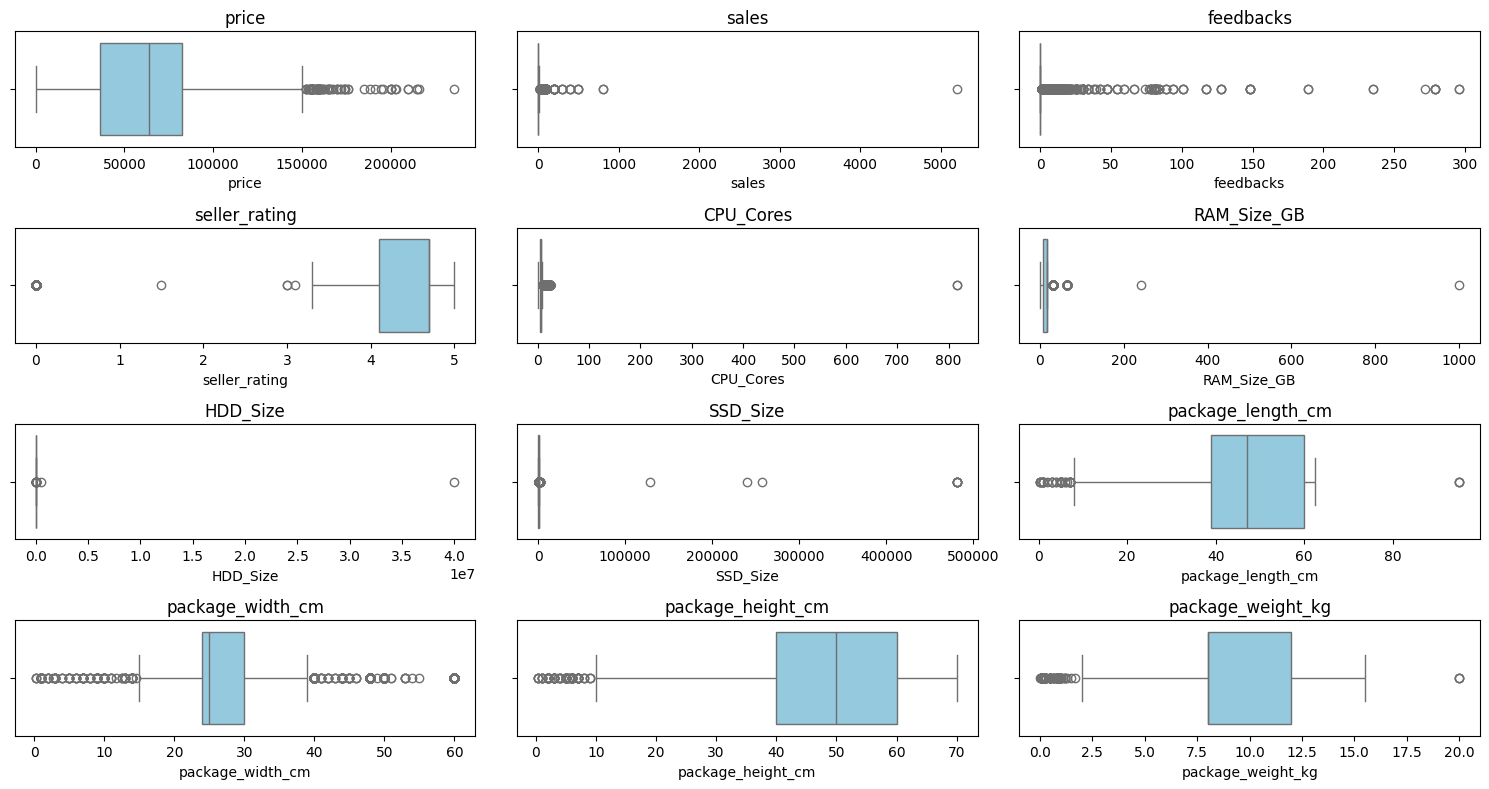

In [ ]:
draw_boxplots(df_ready_wo_dup, num_features)

In [ ]:
df_raw_wo_outliers = df_ready_wo_dup.copy()

# Явные выбросы или ошибки
df_raw_wo_outliers = df_raw_wo_outliers[df_raw_wo_outliers['CPU_Cores'] <= 64]
df_raw_wo_outliers = df_raw_wo_outliers[df_raw_wo_outliers['RAM_Size_GB'] <= 128]
df_raw_wo_outliers = df_raw_wo_outliers[df_raw_wo_outliers['HDD_Size'] <= 20_000]           # в ГБ
df_raw_wo_outliers = df_raw_wo_outliers[df_raw_wo_outliers['SSD_Size'] <= 2048]             # в ГБ

# Усечка
df_raw_wo_outliers['sales'] = df_raw_wo_outliers['sales'].clip(upper=200)
df_raw_wo_outliers['feedbacks'] = df_raw_wo_outliers['feedbacks'].clip(upper=100)
df_raw_wo_outliers['price'] = df_raw_wo_outliers['price'].clip(upper=200000)
df_raw_wo_outliers['seller_rating'] = df_raw_wo_outliers['seller_rating'].clip(lower=3.0)
df_raw_wo_outliers['HDD_Size'] = df_raw_wo_outliers['HDD_Size'].clip(upper=1024)
df_raw_wo_outliers['SSD_Size'] = df_raw_wo_outliers['SSD_Size'].clip(upper=1024)

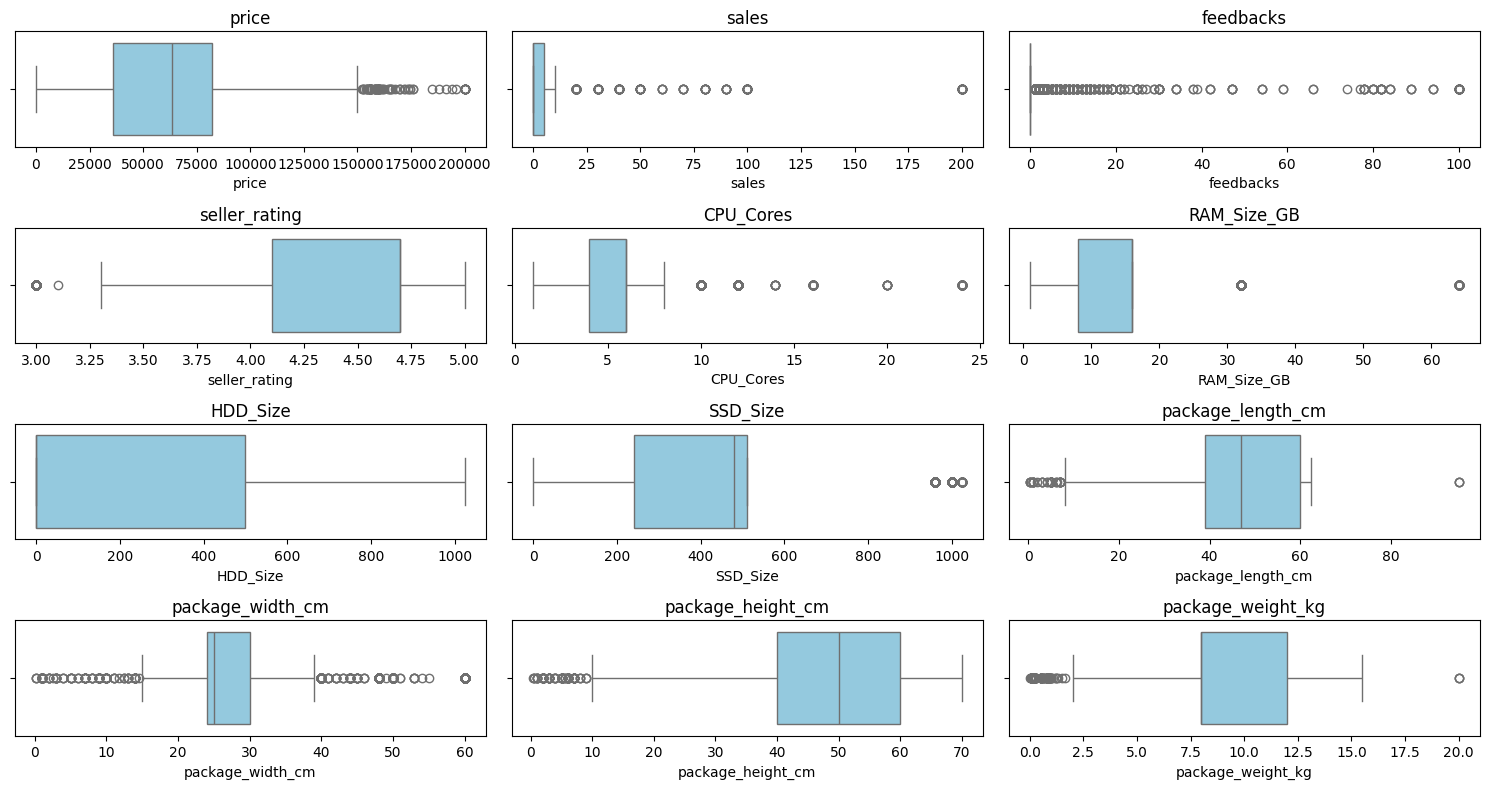

In [ ]:
draw_boxplots(df_raw_wo_outliers, num_features)

In [ ]:
print("Изменение в количестве записей")
print(f"{df_ready_wo_dup.shape[0]} - {df_raw_wo_outliers.shape[0]} = {df_ready_wo_dup.shape[0] - df_raw_wo_outliers.shape[0]}")


Изменение в количестве записей
3983 - 3968 = 15


In [ ]:
df_ready_wo_dup['sales'].unique()

<IntegerArray>
[400, 0, 10, 200, 40, 5, 30, 20, 50, 500, 100, 80, 800, 90, 300, 60, 70, 5200]
Length: 18, dtype: Int64

#### Вывод:
1.Были удалены явные выбросы — например, слишком большое число ядер процессора (более 64) или очень большой объём HDD (больше 20 ТБ), которые скорее всего являются ошибками.

2.Оставшиеся редкие значения (например, 32 ГБ оперативной памяти или более 200 отзывов) могли быть настоящими данными, поэтому их не стали полностью удалять, чтобы не потерять важную информацию и не исказить распределение.

3.Вместо удаления таких выбросов применили обрезку (clipping) значений по верхним и нижним границам, что позволяет сгладить экстремумы и сохранить данные.

Далее для подготовки данных к обучению моделей рекомендуется выполнить масштабирование признаков, например, с помощью StandardScaler или RobustScaler.

### Финальный вид очищенного датафрейма

In [ ]:
df_raw_wo_outliers.head()

,product_id,price,sales,feedbacks,seller,seller_rating,GPU,Operating_System,CPU_Type,CPU_Cores,RAM_Type,RAM_Size_GB,HDD_Size,SSD_Size,package_length_cm,package_width_cm,package_height_cm,package_weight_kg
0,10148385,10805.0,200,7,Other,4.7,Intel,No_OS,Intel Celeron,2,DDR,4,0,0,43.5,12.5,34.0,5.0
1,17877962,32900.0,0,0,Other,4.7,Other,No_OS,Intel Core i5,6,Other,16,0,256,43.0,25.0,50.0,8.0
2,17880420,35720.0,0,0,Other,4.7,Other,No_OS,не заполнено,2,Other,16,0,512,46.0,25.0,50.0,8.0
3,19347937,39237.0,10,1,Robotcomp,4.7,Intel,Windows,Intel Core i5,6,DDR,8,0,480,60.0,30.0,60.0,8.0
4,19348951,76188.0,200,94,Robotcomp,4.7,Nvidia,Windows,Intel Core i5,6,DDR,16,0,960,50.0,24.0,50.0,8.0


### Загрузка датафрейма в .csv файл

In [ ]:
df_raw_wo_outliers.to_csv('data_clear.csv', index=False)


## Итог по очистке и подготовке данных

В ходе работы был выполнен комплексный процесс очистки и преобразования данных:

- Удалены лишние и дублирующие признаки, что позволило сократить размер и повысить качество датасета.  
- Распакованы вложенные словари, чтобы сделать данные более удобными для анализа.  
- Заполнены пропущенные значения с минимальной потерей информации — использованы медианные значения, групповые замены и специальные метки ("unknown").  
- Стандартизированы категориальные признаки с помощью словарей преобразования для устранения вариативности и дубликатов.  
- Удалены полные дубликаты записей.  
- Обнаружены и удалены явные ошибки и выбросы (например, нереалистичные значения CPU-ядер и объёмов памяти).  
- Остальные выбросы не удалялись, а ограничивались с помощью обрезки (clipping), чтобы сохранить важные, но редкие данные.  

В результате получен качественный, структурированный и подготовленный для дальнейшего анализа и построения моделей машинного обучения датафрейм.


### Рекомендации для Заказчика (Этап Внедрения - Deployment)

Для успешного выхода на онлайн-рынок и повышения конкурентоспособности предлагаем следующие ключевые рекомендации:

* **Фокус на качестве данных**: Внедрите строгий контроль за полнотой и корректностью собираемой информации. Качественные данные – основа для точных выводов и эффективных решений.
* **Оптимизация ассортимента**: Регулярно анализируйте, какие технические характеристики компьютеров (CPU, RAM, SSD, GPU) наиболее востребованы. Сосредоточьтесь на сборке ПК, отвечающих текущему рыночному спросу, чтобы максимизировать продажи.
* **Гибкое ценообразование**: Используйте данные анализа для установки конкурентных цен. Понимание факторов, влияющих на цену и спрос, позволит оптимизировать вашу ценовую стратегию.
* **Работа с репутацией**: Активно управляйте отзывами клиентов и стремитесь к высоким рейтингам продавца. Положительная репутация напрямую влияет на выбор покупателей.
* **Автоматизация аналитики**: Рассмотрите возможность автоматизации сбора, очистки и анализа данных. Это ускорит принятие решений и позволит оперативно реагировать на изменения рынка.
* **Прогнозное планирование**: Используйте аналитические прогнозы для более эффективного планирования закупок комплектующих и объемов сборки, минимизируя издержки.

Применение этих рекомендаций поможет заказчику  успешно стартовать на онлайн-рынке, увеличить продажи и укрепить свои позиции.